# Exotics in Isolation

Round 4 manual challenge. Advisor's first lesson:

> **Look at the exotic payoff in isolation first. Then ask what happens when you layer vanilla calls or puts alongside it.**

This notebook does the **first half**: for each exotic, plot the terminal payoff as a function of state and ask **what makes it different from a vanilla**. The pure-vanilla intuition is

$$\text{payoff} = f(S_T)$$

i.e., one number per path: the spot at expiry. Exotics break this. Each one will surface a *new axis* of risk that vanilla intuition cannot see.

Underlying: `AETHER_CRYSTAL`. GBM with $\sigma=251\%$, $r=0$, $S_0=49.975$. Expiries 14d (2-week) and 21d (3-week); time grid 4 ticks/day.

## Setup

Two pieces of state used throughout:

1. **`MARKET`** — single source of truth for every contract spec. Each entry holds the contract name, type, strike, barrier (if any), `binary_put_payout` (digital contracts only), expiry tick, decision tick (chooser only), and the live bid/ask off the screenshot. **Every later cell pulls its numbers from here.**
2. **Time-grid aliases** — readable names for `mc_engine`'s tick constants so we never have to remember whether `T1_STEPS` means "two-week expiry" or "chooser decision" (it's both).

In [92]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from mc_engine import (
    simulate_paths, S0, DT, T1_STEPS, T2_STEPS,
    call_payoff, put_payoff,
    binary_put_payoff, knockout_put_payoff, chooser_payoff,
    bs_call, bs_put, mc_price,
)

# --- Time-grid: readable aliases for the engine's tick counts ---
INITIAL_SPOT             = S0          # 49.975
YEAR_FRACTION_PER_TICK   = DT          # 1 / (252 * 4)
TICK_AT_2W_EXPIRY        = T1_STEPS    # 14d * 4 = 56 ticks  (also the chooser decision tick)
TICK_AT_3W_EXPIRY        = T2_STEPS    # 21d * 4 = 84 ticks
TICK_AT_CHOOSER_DECISION = T1_STEPS    # same number as 2w expiry, but conceptually different
NUM_PATHS                = 30_000
RANDOM_SEED              = 7

# --- MARKET: single source of truth for every contract on the platform ---
MARKET = {
    'AC_50_C':   {'kind': 'call',       'strike': 50, 'expiry_tick': TICK_AT_3W_EXPIRY,
                  'bid': 12.00,  'ask': 12.05},
    'AC_50_P':   {'kind': 'put',        'strike': 50, 'expiry_tick': TICK_AT_3W_EXPIRY,
                  'bid': 12.00,  'ask': 12.05},
    'AC_35_P':   {'kind': 'put',        'strike': 35, 'expiry_tick': TICK_AT_3W_EXPIRY,
                  'bid':  4.33,  'ask':  4.35},
    'AC_40_P':   {'kind': 'put',        'strike': 40, 'expiry_tick': TICK_AT_3W_EXPIRY,
                  'bid':  6.50,  'ask':  6.55},
    'AC_45_P':   {'kind': 'put',        'strike': 45, 'expiry_tick': TICK_AT_3W_EXPIRY,
                  'bid':  9.05,  'ask':  9.10},
    'AC_60_C':   {'kind': 'call',       'strike': 60, 'expiry_tick': TICK_AT_3W_EXPIRY,
                  'bid':  8.80,  'ask':  8.85},
    'AC_50_C_2': {'kind': 'call',       'strike': 50, 'expiry_tick': TICK_AT_2W_EXPIRY,
                  'bid':  9.70,  'ask':  9.75},
    'AC_50_P_2': {'kind': 'put',        'strike': 50, 'expiry_tick': TICK_AT_2W_EXPIRY,
                  'bid':  9.70,  'ask':  9.75},
    'AC_40_BP':  {'kind': 'binary_put', 'strike': 40, 'expiry_tick': TICK_AT_3W_EXPIRY,
                  'binary_put_payout': 10.0, 'bid': 5.00, 'ask': 5.10},
    # AC_45_KO: Strike 45, Barrier 35 (confirmed from manual.md)
    'AC_45_KO':  {'kind': 'ko_put',     'strike': 45, 'barrier': 35, 'expiry_tick': TICK_AT_3W_EXPIRY,
                  'bid': 0.15, 'ask': 0.175},
    'AC_50_CO':  {'kind': 'chooser',    'strike': 50, 'expiry_tick': TICK_AT_3W_EXPIRY,
                  'decision_tick': TICK_AT_CHOOSER_DECISION, 'bid': 22.20, 'ask': 22.30},
}

# Simulate one batch of GBM paths; reuse for every plot
paths = simulate_paths(NUM_PATHS, n_steps=TICK_AT_3W_EXPIRY, seed=RANDOM_SEED)

# Convenient slices off those paths (intuitive names, no indexing in later cells)
spot_at_3w_expiry        = paths[:, TICK_AT_3W_EXPIRY]
spot_at_2w_expiry        = paths[:, TICK_AT_2W_EXPIRY]
spot_at_chooser_decision = paths[:, TICK_AT_CHOOSER_DECISION]
min_spot_over_path       = paths.min(axis=1)

print(f'paths shape: {paths.shape}')
print(f'E[S_T] over paths: {spot_at_3w_expiry.mean():.3f}  (martingale check, target ~ S0={INITIAL_SPOT})')

paths shape: (30000, 85)
E[S_T] over paths: 50.133  (martingale check, target ~ S0=49.975)


## 1. Vanilla baseline — one axis is enough

A vanilla call/put depends only on `S_T`. Plot payoff vs spot at expiry. Hockey stick. No surprises. This is the intuition that exotics will break.

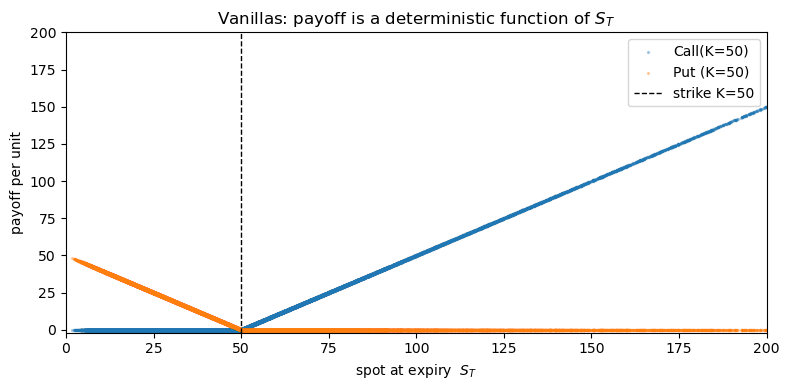

In [93]:
vanilla_call = MARKET['AC_50_C']
vanilla_put  = MARKET['AC_50_P']
atm_strike   = vanilla_call['strike']

vanilla_call_payoff_per_unit = call_payoff(spot_at_3w_expiry, atm_strike)
vanilla_put_payoff_per_unit  = put_payoff (spot_at_3w_expiry, atm_strike)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(spot_at_3w_expiry, vanilla_call_payoff_per_unit, s=2, alpha=0.3,
           label=f'Call(K={atm_strike})')
ax.scatter(spot_at_3w_expiry, vanilla_put_payoff_per_unit,  s=2, alpha=0.3,
           label=f'Put (K={atm_strike})')
ax.axvline(atm_strike, color='k', ls='--', lw=1, label=f'strike K={atm_strike}')
ax.set(xlabel='spot at expiry  $S_T$', ylabel='payoff per unit',
       title='Vanillas: payoff is a deterministic function of $S_T$',
       xlim=(0, 200), ylim=(-2, 200))
ax.legend(); plt.tight_layout(); plt.show()

**Read this:** every dot lies *exactly* on the hockey-stick. There is no scatter. Knowing `S_T` tells you the payoff with certainty — that is what "path-independent" means.

Now we will see exotics where two paths with the **same** `S_T` give **different** payoffs. The vertical scatter at a fixed `S_T` is the new axis of risk.

## 2. Binary put — vanilla intuition still works (no path dependence)

**Contract:** `AC_40_BP`. Pays a fixed `binary_put_payout` if $S_T < K_\text{bin}$; otherwise nothing.

$$\text{payoff} = \text{binary\_put\_payout} \cdot \mathbf{1}\{S_T < K_\text{bin}\}$$

Even though it's an exotic, the payoff still depends only on `S_T`. The new wrinkle is that the payoff is a **step function** rather than a hockey stick: dollar-cliff risk at the strike, and you cannot delta-hedge cleanly through that cliff.

P(S_T < 40)         = 0.522
Fair (binary_put_payout=10.0) = 5.222
Market bid 5.0/ask 5.1 mid 5.050  ->  edge per unit = +0.172


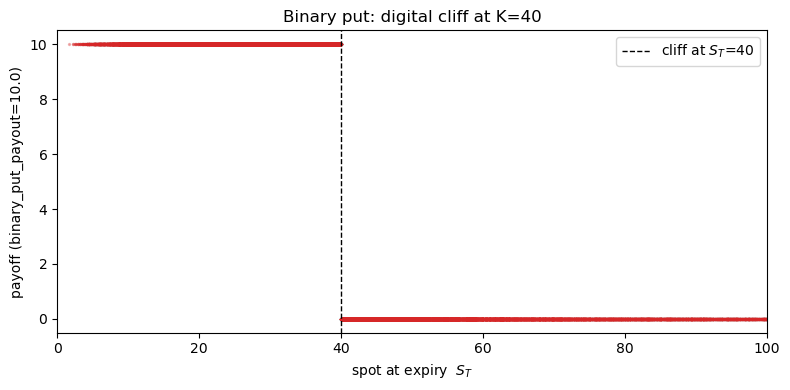

In [94]:
binary_put_spec    = MARKET['AC_40_BP']
binary_put_strike  = binary_put_spec['strike']
binary_put_payout  = binary_put_spec['binary_put_payout']

binary_put_payoff_per_unit = binary_put_payoff(spot_at_3w_expiry,
                                               binary_put_strike,
                                               amount=binary_put_payout)
prob_finishing_below_strike = (spot_at_3w_expiry < binary_put_strike).mean()
fair_value_per_unit = binary_put_payoff_per_unit.mean()
market_mid          = 0.5 * (binary_put_spec['bid'] + binary_put_spec['ask'])

print(f'P(S_T < {binary_put_strike})         = {prob_finishing_below_strike:.3f}')
print(f'Fair (binary_put_payout={binary_put_payout}) = {fair_value_per_unit:.3f}')
print(f"Market bid {binary_put_spec['bid']}/ask {binary_put_spec['ask']} mid {market_mid:.3f}"
      f'  ->  edge per unit = {fair_value_per_unit - market_mid:+.3f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(spot_at_3w_expiry, binary_put_payoff_per_unit, s=2, alpha=0.3, color='C3')
ax.axvline(binary_put_strike, color='k', ls='--', lw=1,
           label=f'cliff at $S_T$={binary_put_strike}')
ax.set(xlabel='spot at expiry  $S_T$',
       ylabel=f'payoff (binary_put_payout={binary_put_payout})',
       title=f'Binary put: digital cliff at K={binary_put_strike}',
       xlim=(0, 100))
ax.legend(); plt.tight_layout(); plt.show()

**Read this:** payoff is either 0 or `binary_put_payout` — no in-between. Each dot is on one of two horizontal lines.

### Replication: digital ≈ tight bull-put spread

A digital cliff cannot be built exactly from continuous put payoffs (puts are kinked, not jumps). But a *bull-put spread* — long one put at $K+\varepsilon$, short one at $K-\varepsilon$, both struck around the digital's strike $K$ — produces a **ramped digital** that converges to the cliff as $\varepsilon \to 0$.

**Construction.** With payout $A$:

$$\text{replication payoff}(S_T) \;=\; \frac{A}{2\varepsilon}\,\bigl[P(K+\varepsilon)\;-\;P(K-\varepsilon)\bigr]$$

Where $P(K')$ means a vanilla put with strike $K'$. Walk the three regions of $S_T$:

| Region | Long put $P(K+\varepsilon)$ | Short put $-P(K-\varepsilon)$ | Sum | Scaled by $A/2\varepsilon$ |
|---|---|---|---|---|
| $S_T \ge K+\varepsilon$ | $0$ | $0$ | $0$ | $0$ |
| $K-\varepsilon \le S_T < K+\varepsilon$ | $K+\varepsilon - S_T$ | $0$ | $K+\varepsilon - S_T$ | $\dfrac{A(K+\varepsilon - S_T)}{2\varepsilon}$ |
| $S_T < K-\varepsilon$ | $K+\varepsilon - S_T$ | $-(K-\varepsilon - S_T)$ | $2\varepsilon$ | $A$ |

Outside the band the replication matches the digital (0 above, $A$ below). Inside the band, the digital cliff is replaced by a **linear ramp** from $A$ at $S_T = K-\varepsilon$ down to $0$ at $S_T = K+\varepsilon$.

**Why it works (calculus view).** Recall $\partial P/\partial K = \mathbf{P}(S_T < K)$ under the risk-neutral measure (Breeden–Litzenberger). So a digital put fair value equals $A \cdot \partial P/\partial K \big|_{K}$. The bull-put spread is a *finite-difference* approximation of that derivative: $\frac{P(K+\varepsilon) - P(K-\varepsilon)}{2\varepsilon} \to \partial P/\partial K$ as $\varepsilon \to 0$. They agree at first order, and the residual is $O(\varepsilon^2)$.

**This contract.** $K = 40$, $A = 10$, available strikes $\{35, 40, 45\}$. Pick $\varepsilon = 5$ (largest possible — coarsest spread):

$$\text{replication} \;=\; \frac{10}{2 \cdot 5}\,\bigl[P(45) - P(35)\bigr] \;=\; P(45) - P(35)$$

So one synthetic digital = long one `AC_45_P` + short one `AC_35_P`. The ramp band is $[35, 45]$ — wide, so replication is quite imperfect. The next code cell prices it at touch and visualizes the residual.

--- fair values (per unit, MC) ---
  digital fair        = 5.222
  replication fair    = 5.207
  fair gap (digital - replication) = +0.015

--- prices at touch (per unit) ---
  binary put ask 5.100 / bid 5.000
  replication: buy at 4.770 / sell at 4.700

--- arb candidates ---
  (A) buy repl @ 4.770, sell digital @ 5.000  ->  credit +0.230,  E[terminal] -0.015,  total E[PnL] +0.215 per unit
  (B) sell repl @ 4.700, buy digital @ 5.100  ->  credit -0.400,  E[terminal] +0.015,  total E[PnL] -0.385 per unit
Worst case S_T just below 40: residual = −4.77 per unit (loss ~$715k worst-case across full size). Best case S_T just below 45: residual = +5.23 per unit. Outside [35,45]: locked-in +0.23.


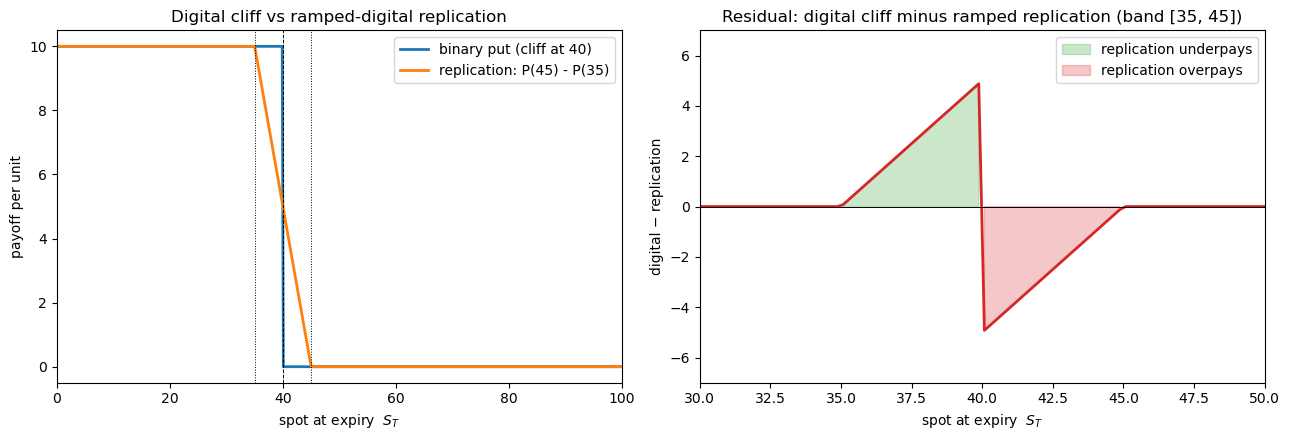

In [102]:
# --- Build the bull-put-spread replication for the binary put ---
put_low_spec  = MARKET['AC_35_P']    # short leg (K - epsilon)
put_high_spec = MARKET['AC_45_P']    # long  leg (K + epsilon)
strike_low    = put_low_spec['strike']
strike_high   = put_high_spec['strike']
epsilon       = (strike_high - strike_low) / 2.0          # = 5
spread_scale  = binary_put_payout / (2.0 * epsilon)       # = 10/10 = 1

# Replication payoff per path = scale * [P(K+eps) - P(K-eps)]
put_low_payoff_per_unit  = put_payoff(spot_at_3w_expiry, strike_low)
put_high_payoff_per_unit = put_payoff(spot_at_3w_expiry, strike_high)
replication_payoff_per_unit = spread_scale * (put_high_payoff_per_unit - put_low_payoff_per_unit)
replication_fair_value      = replication_payoff_per_unit.mean()

# At-touch prices: long replication = buy P(45) at ask, sell P(35) at bid
cost_to_buy_replication      = spread_scale * (put_high_spec['ask'] - put_low_spec['bid'])
proceeds_to_sell_replication = spread_scale * (put_high_spec['bid'] - put_low_spec['ask'])

print('--- fair values (per unit, MC) ---')
print(f'  digital fair        = {fair_value_per_unit:.3f}')
print(f'  replication fair    = {replication_fair_value:.3f}')
print(f'  fair gap (digital - replication) = {fair_value_per_unit - replication_fair_value:+.3f}')
print('\n--- prices at touch (per unit) ---')
print(f"  binary put ask {binary_put_spec['ask']:.3f} / bid {binary_put_spec['bid']:.3f}")
print(f'  replication: buy at {cost_to_buy_replication:.3f} / sell at {proceeds_to_sell_replication:.3f}')

# --- Two static-arb candidates against the live book ---
# (A) BUY replication, SELL binary
#     initial cash flow  = bid_binary - cost_to_buy_replication           (credit if positive)
#     terminal cash flow = replication_payoff - binary_payoff             (long repl, short binary)
# (B) SELL replication, BUY binary  (mirror image)
credit_A            = binary_put_spec['bid'] - cost_to_buy_replication
expected_terminal_A = (replication_payoff_per_unit - binary_put_payoff_per_unit).mean()
credit_B            = proceeds_to_sell_replication - binary_put_spec['ask']
expected_terminal_B = (binary_put_payoff_per_unit - replication_payoff_per_unit).mean()

print('\n--- arb candidates ---')
print(f'  (A) buy repl @ {cost_to_buy_replication:.3f}, sell digital @ {binary_put_spec["bid"]:.3f}'
      f'  ->  credit {credit_A:+.3f},  E[terminal] {expected_terminal_A:+.3f},'
      f'  total E[PnL] {credit_A + expected_terminal_A:+.3f} per unit')
print(f'  (B) sell repl @ {proceeds_to_sell_replication:.3f}, buy digital @ {binary_put_spec["ask"]:.3f}'
      f'  ->  credit {credit_B:+.3f},  E[terminal] {expected_terminal_B:+.3f},'
      f'  total E[PnL] {credit_B + expected_terminal_B:+.3f} per unit')


print("Worst case S_T just below 40: residual = −4.77 per unit (loss ~$715k worst-case across full size). Best case S_T just below 45: residual = +5.23 per unit. Outside [35,45]: locked-in +0.23.")
# --- Visualize: digital vs replication payoff vs S_T, plus residual ---
xs = np.linspace(0, 100, 500)
digital_curve     = binary_put_payout * (xs < binary_put_strike).astype(float)
replication_curve = spread_scale * (put_payoff(xs, strike_high) - put_payoff(xs, strike_low))
residual_curve    = digital_curve - replication_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(xs, digital_curve, lw=2, label=f'binary put (cliff at {binary_put_strike})')
ax.plot(xs, replication_curve, lw=2, label=f'replication: P({strike_high}) - P({strike_low})')
ax.axvline(strike_low, color='k', ls=':', lw=0.7)
ax.axvline(binary_put_strike, color='k', ls='--', lw=0.7)
ax.axvline(strike_high, color='k', ls=':', lw=0.7)
ax.set(xlabel='spot at expiry  $S_T$', ylabel='payoff per unit',
       title='Digital cliff vs ramped-digital replication', xlim=(0, 100))
ax.legend()

ax = axes[1]
ax.plot(xs, residual_curve, color='C3', lw=2)
ax.axhline(0, color='k', lw=0.7)
ax.fill_between(xs, residual_curve, 0, where=(residual_curve > 0), alpha=0.25, color='C2',
                label='replication underpays')
ax.fill_between(xs, residual_curve, 0, where=(residual_curve < 0), alpha=0.25, color='C3',
                label='replication overpays')
ax.set(xlabel='spot at expiry  $S_T$', ylabel='digital − replication',
       title=f'Residual: digital cliff minus ramped replication (band [{strike_low}, {strike_high}])',
       xlim=(30, 50), ylim=(-7, 7))
ax.legend()
plt.tight_layout(); plt.show()



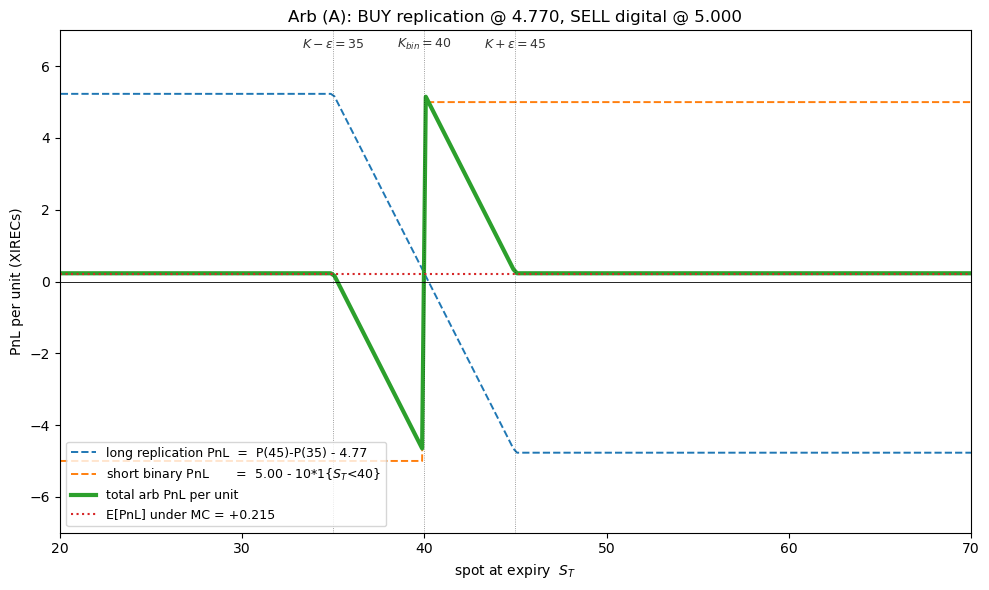

S_T < 35                : PnL = +0.230   (repl pays 10, binary pays 10; legs cancel; only credit remains)
35 <= S_T < 40        : PnL = +0.230 + (S_T - 35*1)  ... ramps from +0.230 at S_T=35 down to -4.770 at S_T=40 (worst)
40 <= S_T < 45        : PnL = +0.230 + (45 - S_T)   ... ramps from +5.230 at S_T=40 (best) down to +0.230 at S_T=45
S_T >= 45               : PnL = +0.230   (both payoffs zero; only credit)

E[PnL] (MC) = +0.215 per unit
Scaled to max size 50 contracts * 3000 multiplier: E[PnL] = +32,196 XIRECs


In [104]:
# --- PnL of arb (A): BUY replication, SELL digital, vs S_T ---
# Per unit, decomposed into the two legs:
#   long replication leg PnL  = replication_payoff - cost_to_buy_replication
#   short binary       leg PnL = bid_binary - binary_payoff
xs = np.linspace(0, 100, 500)
replication_curve_xs = spread_scale * (put_payoff(xs, strike_high) - put_payoff(xs, strike_low))
binary_curve_xs      = binary_put_payout * (xs < binary_put_strike).astype(float)

leg_long_repl_pnl    = replication_curve_xs - cost_to_buy_replication
leg_short_binary_pnl = binary_put_spec['bid'] - binary_curve_xs
total_arb_pnl_xs     = leg_long_repl_pnl + leg_short_binary_pnl

expected_pnl = credit_A + expected_terminal_A   # already computed above

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(xs, leg_long_repl_pnl,    lw=1.4, ls='--', color='C0',
        label=f'long replication PnL  =  P({strike_high})-P({strike_low}) - {cost_to_buy_replication:.2f}')
ax.plot(xs, leg_short_binary_pnl, lw=1.4, ls='--', color='C1',
        label=f'short binary PnL       =  {binary_put_spec["bid"]:.2f} - {binary_put_payout:.0f}*1{{$S_T$<{binary_put_strike}}}')
ax.plot(xs, total_arb_pnl_xs, lw=3, color='C2',
        label='total arb PnL per unit')
ax.axhline(0, color='k', lw=0.6)
ax.axhline(expected_pnl, color='C3', ls=':', lw=1.5,
           label=f'E[PnL] under MC = {expected_pnl:+.3f}')

# Vertical strike markers
for x, lbl in [(strike_low, f'$K-\\varepsilon={strike_low}$'),
               (binary_put_strike, f'$K_{{bin}}={binary_put_strike}$'),
               (strike_high, f'$K+\\varepsilon={strike_high}$')]:
    ax.axvline(x, color='k', ls=':', lw=0.6, alpha=0.5)
    ax.text(x, 6.5, lbl, ha='center', fontsize=9, alpha=0.8)

ax.set(xlabel='spot at expiry  $S_T$', ylabel='PnL per unit (XIRECs)',
       title=f"Arb (A): BUY replication @ {cost_to_buy_replication:.3f}, SELL digital @ {binary_put_spec['bid']:.3f}",
       xlim=(20, 70), ylim=(-7, 7))
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout(); plt.show()

# Region-by-region readout
print(f'S_T < {strike_low}                : PnL = {credit_A:+.3f}   '
      f'(repl pays {binary_put_payout:.0f}, binary pays {binary_put_payout:.0f}; legs cancel; only credit remains)')
print(f'{strike_low} <= S_T < {binary_put_strike}        : PnL = {credit_A:+.3f} + (S_T - {strike_low}*1)  '
      f'... ramps from {credit_A:+.3f} at S_T={strike_low} down to {credit_A + (strike_high - binary_put_strike) - binary_put_payout:+.3f} at S_T={binary_put_strike} (worst)')
print(f'{binary_put_strike} <= S_T < {strike_high}        : PnL = {credit_A:+.3f} + ({strike_high} - S_T)   '
      f'... ramps from {credit_A + (strike_high - binary_put_strike):+.3f} at S_T={binary_put_strike} (best) down to {credit_A:+.3f} at S_T={strike_high}')
print(f'S_T >= {strike_high}               : PnL = {credit_A:+.3f}   (both payoffs zero; only credit)')
print(f'\nE[PnL] (MC) = {expected_pnl:+.3f} per unit')
print(f'Scaled to max size 50 contracts * 3000 multiplier: '
      f'E[PnL] = {50*3000*expected_pnl:+,.0f} XIRECs')

Per-unit PnL stats over 30,000 paths:
  mean       = +0.215
  std        = +1.069
  min        = -4.769
  max        = +5.230
  p05        = -1.289
  p50        = +0.230
  p95        = +1.454
  win_rate   = +0.930
  sharpe   = +0.201   (mean / std)

At max size (50 contracts * 3000 multiplier):
  E[PnL]    = +32,196
  std[PnL]  = +160,366
  5th pctl  = -193,311   (5% chance of losing more than this)

--- comparison of single-leg trades (per unit) ---
  arb (A): buy repl, sell binary   E=+0.215  std=1.069  sharpe=+0.201
  long binary at ask               E=+0.122  std=4.995  sharpe=+0.024
  long P(45) at ask                E=+2.010  std=12.191  sharpe=+0.165
  short P(35) at bid               E=-1.573  std=8.329  sharpe=-0.189


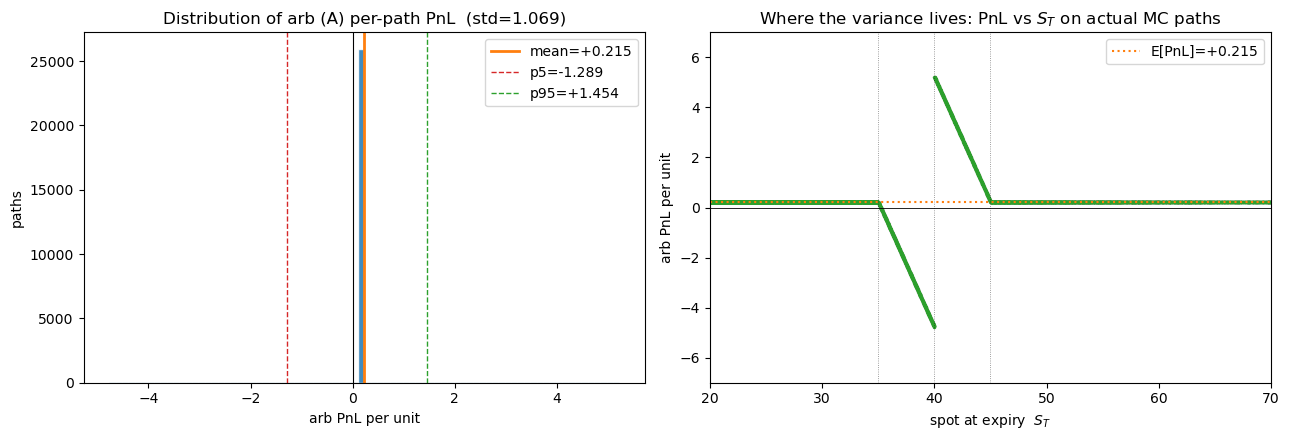


--- can the residual be smoothed further? ---
With strikes {35, 40, 45} and a digital at K=40, A=10, NO linear combination
of the three vanilla puts replicates the cliff exactly:
  - in 40 <= S_T < 45 the digital is 0, but P(45) is still active there;
    forcing its weight to 0 to zero the region also kills the spread.
Best replication from these strikes is the symmetric bull-put-spread (eps=5).
Tighter would need P(38) or P(42), which are not listed.

Variance-reduction options that ARE available:
 1. Trade < 50 contracts; std and worst-case scale linearly with size.
 2. Skip the spread; just LONG the binary at ask 5.10 (E[PnL] = 0.122 per unit,
    but the digital cliff is the only state risk -- variance is structurally lower).
 3. Skip the spread; LONG P(45) alone -- the put leg is where most of the edge
    actually comes from (the market is underpricing all puts under sigma=251%).
    Higher std but cleaner exposure.


In [107]:
# --- Variance of arb (A) per path ---
# Per-path PnL of long replication + short binary, including initial credit.
arb_pnl_per_path = (replication_payoff_per_unit - cost_to_buy_replication) \
                 + (binary_put_spec['bid'] - binary_put_payoff_per_unit)

stats = {
    'mean':  arb_pnl_per_path.mean(),
    'std':   arb_pnl_per_path.std(ddof=1),
    'min':   arb_pnl_per_path.min(),
    'max':   arb_pnl_per_path.max(),
    'p05':   np.percentile(arb_pnl_per_path, 5),
    'p50':   np.percentile(arb_pnl_per_path, 50),
    'p95':   np.percentile(arb_pnl_per_path, 95),
    'win_rate': (arb_pnl_per_path > 0).mean(),
}
sharpe = stats['mean'] / stats['std']
print(f"Per-unit PnL stats over {len(arb_pnl_per_path):,} paths:")
for k, v in stats.items():
    print(f"  {k:10s} = {v:+.3f}" if isinstance(v, float) else f"  {k:10s} = {v}")
print(f"  sharpe   = {sharpe:+.3f}   (mean / std)")
print(f"\nAt max size (50 contracts * 3000 multiplier):")
print(f"  E[PnL]    = {50*3000*stats['mean']:+,.0f}")
print(f"  std[PnL]  = {50*3000*stats['std']:+,.0f}")
print(f"  5th pctl  = {50*3000*stats['p05']:+,.0f}   (5% chance of losing more than this)")

# --- Compare with simpler trades that use the same edge but different variance ---
buy_binary_pnl  = binary_put_payoff_per_unit - binary_put_spec['ask']    # long binary at ask
long_p45_pnl    = put_high_payoff_per_unit  - put_high_spec['ask']       # long P(45) at ask alone
short_p35_pnl   = put_low_spec['bid']       - put_low_payoff_per_unit    # short P(35) at bid alone

print('\n--- comparison of single-leg trades (per unit) ---')
for name, x in [('arb (A): buy repl, sell binary', arb_pnl_per_path),
                ('long binary at ask',             buy_binary_pnl),
                ('long P(45) at ask',              long_p45_pnl),
                ('short P(35) at bid',             short_p35_pnl)]:
    m, s = x.mean(), x.std(ddof=1)
    print(f"  {name:32s} E={m:+.3f}  std={s:.3f}  sharpe={m/s:+.3f}")

# --- Histogram and S_T-conditional view ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.hist(arb_pnl_per_path, bins=80, color='C0', edgecolor='white', alpha=0.85)
ax.axvline(0, color='k', lw=0.8)
ax.axvline(stats['mean'], color='C1', lw=2, label=f"mean={stats['mean']:+.3f}")
ax.axvline(stats['p05'],  color='C3', ls='--', lw=1, label=f"p5={stats['p05']:+.3f}")
ax.axvline(stats['p95'],  color='C2', ls='--', lw=1, label=f"p95={stats['p95']:+.3f}")
ax.set(xlabel='arb PnL per unit', ylabel='paths',
       title=f'Distribution of arb (A) per-path PnL  (std={stats["std"]:.3f})')
ax.legend()

ax = axes[1]
ax.scatter(spot_at_3w_expiry, arb_pnl_per_path, s=2, alpha=0.25, color='C2')
ax.axhline(0, color='k', lw=0.6)
ax.axhline(stats['mean'], color='C1', ls=':', lw=1.5, label=f"E[PnL]={stats['mean']:+.3f}")
for x in (strike_low, binary_put_strike, strike_high):
    ax.axvline(x, color='k', ls=':', lw=0.6, alpha=0.5)
ax.set(xlabel='spot at expiry  $S_T$', ylabel='arb PnL per unit',
       title='Where the variance lives: PnL vs $S_T$ on actual MC paths',
       xlim=(20, 70), ylim=(-7, 7))
ax.legend()
plt.tight_layout(); plt.show()

# --- Why we cannot smooth further from listed strikes ---
print("\n--- can the residual be smoothed further? ---")
print("With strikes {35, 40, 45} and a digital at K=40, A=10, NO linear combination")
print("of the three vanilla puts replicates the cliff exactly:")
print("  - in 40 <= S_T < 45 the digital is 0, but P(45) is still active there;")
print("    forcing its weight to 0 to zero the region also kills the spread.")
print("Best replication from these strikes is the symmetric bull-put-spread (eps=5).")
print("Tighter would need P(38) or P(42), which are not listed.\n")
print("Variance-reduction options that ARE available:")
print(" 1. Trade < 50 contracts; std and worst-case scale linearly with size.")
print(" 2. Skip the spread; just LONG the binary at ask 5.10 (E[PnL] = 0.122 per unit,")
print("    but the digital cliff is the only state risk -- variance is structurally lower).")
print(" 3. Skip the spread; LONG P(45) alone -- the put leg is where most of the edge")
print("    actually comes from (the market is underpricing all puts under sigma=251%).")
print("    Higher std but cleaner exposure.")

## 3. Knock-out put — *the* path dependency story

**Contract:** `AC_45_KO`. Strike $K=45$, barrier $B=35$, expiry 21d (confirmed from manual). Acts like a regular put with strike 45 — *unless* the path ever falls below 35 before expiry. Then payoff = 0 forever.

$$\text{payoff} = \mathbf{1}\{\min_{t \le T} S_t \ge B\} \cdot \max(K - S_T, 0)$$

The new axis of risk: **$\min_t S_t$** (the lowest spot reached during life). Two paths with the same $S_T$ pay differently depending on whether either ever dipped below the barrier.

**Why both numbers matter.** Because $B = 35 < K = 45$, the contract has a non-trivial *survival corridor*: paths that finish in $[35, 45)$ AND never dipped below 35. Survivors there pay positive intrinsic. With $\sigma = 251\%$ that corridor is narrow — many paths will breach the barrier — but it is not empty.

In [96]:
ko_put_spec    = MARKET['AC_45_KO']
ko_strike      = ko_put_spec['strike']
ko_barrier     = ko_put_spec['barrier']

ko_put_payoff_per_unit = knockout_put_payoff(paths, K=ko_strike, barrier=ko_barrier)
path_was_knocked_out   = (min_spot_over_path < ko_barrier)
ko_fair_value          = ko_put_payoff_per_unit.mean()
ko_market_mid          = 0.5 * (ko_put_spec['bid'] + ko_put_spec['ask'])

print(f'Strike K = {ko_strike}, Barrier B = {ko_barrier}')
print(f'Fraction of paths that knock out:                {path_was_knocked_out.mean():.3f}')
print(f'Fraction in-the-money at expiry (S_T<{ko_strike}):       '
      f'{(spot_at_3w_expiry < ko_strike).mean():.3f}')
print(f'Fraction in-the-money AND survived (still pays): '
      f'{((spot_at_3w_expiry < ko_strike) & ~path_was_knocked_out).mean():.3f}')
print(f'MC fair value:                                   {ko_fair_value:.6f}')
print(f"Market: bid {ko_put_spec['bid']}/ask {ko_put_spec['ask']} mid {ko_market_mid:.4f}  "
      f'-> edge per unit (vs sell at bid) = {ko_put_spec["bid"] - ko_fair_value:+.4f}')

Strike K = 45, Barrier B = 35
Fraction of paths that knock out:                0.695
Fraction in-the-money at expiry (S_T<45):       0.586
Fraction in-the-money AND survived (still pays): 0.030
MC fair value:                                   0.127798
Market: bid 0.15/ask 0.175 mid 0.1625  -> edge per unit (vs sell at bid) = +0.0222


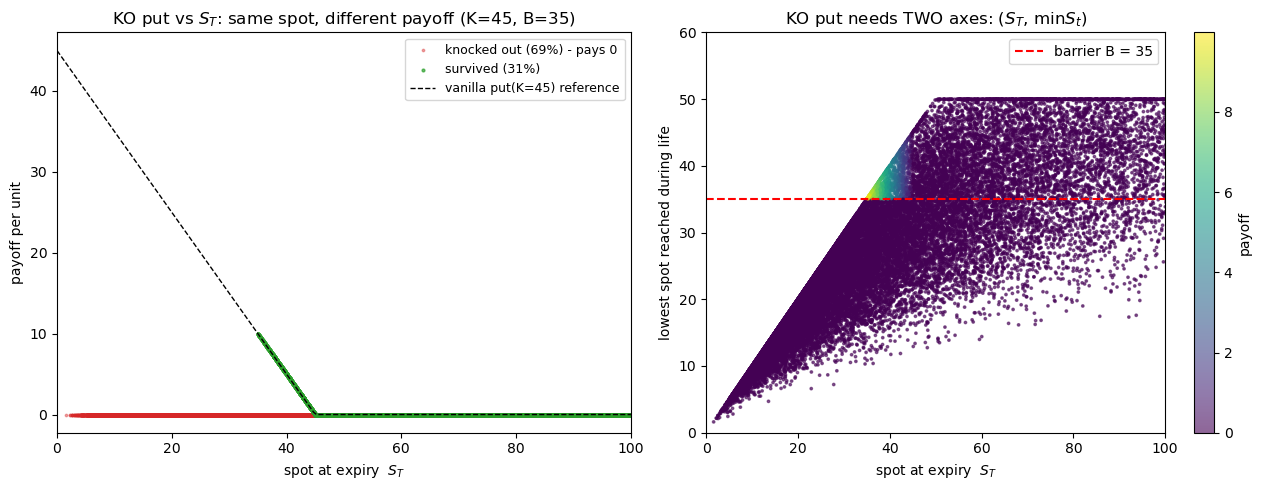

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: payoff vs S_T, colored by barrier-touch outcome
ax = axes[0]
ax.scatter(spot_at_3w_expiry[ path_was_knocked_out],
           ko_put_payoff_per_unit[ path_was_knocked_out],
           s=3, alpha=0.4, color='C3',
           label=f'knocked out ({path_was_knocked_out.mean():.0%}) - pays 0')
ax.scatter(spot_at_3w_expiry[~path_was_knocked_out],
           ko_put_payoff_per_unit[~path_was_knocked_out],
           s=4, alpha=0.7, color='C2',
           label=f'survived ({(~path_was_knocked_out).mean():.0%})')
vanilla_curve_xs = np.linspace(0, 100, 200)
ax.plot(vanilla_curve_xs, put_payoff(vanilla_curve_xs, ko_strike),
        'k--', lw=1, label=f'vanilla put(K={ko_strike}) reference')
ax.set(xlabel='spot at expiry  $S_T$', ylabel='payoff per unit',
       title=f'KO put vs $S_T$: same spot, different payoff (K={ko_strike}, B={ko_barrier})',
       xlim=(0, 100))
ax.legend(fontsize=9)

# Right: 2D state — the *real* picture
ax = axes[1]
scatter = ax.scatter(spot_at_3w_expiry, min_spot_over_path,
                     c=ko_put_payoff_per_unit, s=3, alpha=0.6, cmap='viridis')
ax.axhline(ko_barrier, color='r', ls='--', lw=1.5, label=f'barrier B = {ko_barrier}')
ax.set(xlabel='spot at expiry  $S_T$',
       ylabel='lowest spot reached during life',
       title='KO put needs TWO axes: ($S_T$, $\\min S_t$)',
       xlim=(0, 100), ylim=(0, max(60, min_spot_over_path.max())))
plt.colorbar(scatter, ax=ax, label='payoff')
ax.legend(); plt.tight_layout(); plt.show()

**Read these:**

*Left plot:* at each `S_T < 45`, paths split into red (knocked, pays 0) and green (survived, pays vanilla intrinsic). Green points only appear roughly in `S_T ∈ [35, 45)` — to be ITM `S_T < 45`, and to have survived `min S_t ≥ 35`, which forces `S_T ≥ 35`. That narrow corridor is what gives the contract any value at all.

*Right plot:* the true state space is 2D — `(S_T, min S_t)`. Above the red barrier line `B = 35`, payoff lives. Below, it dies. A vanilla put would produce horizontal stripes (constant in the y-axis); the KO put has a sharp boundary at the barrier.

**Trade implication.** With $\sigma = 251\%$ paths are wild; ~70% breach the 35 barrier. Fair value is small (~0.13 per unit) but **not zero** — there is a real survival corridor, and ~3% of paths pay positive intrinsic. Compare to market mid 0.1625:
- **Sell at bid 0.15** — only marginally above fair (~+0.02 edge per unit). 500-cap × 3000 multiplier ≈ +30k expected, but with real tail risk: the surviving-and-ITM paths can pay close to 10 per unit, so worst-case loss per unit is large.
- **Buy at ask 0.175** — *above* fair, negative edge. Don't.

This is **not** the deterministic free-money trade I claimed when I (wrongly) assumed `B = K`. Sizing needs to weigh the small expected edge against the heavy left tail.

## 4. Chooser — a two-act story

**Contract:** `AC_50_CO`. Strike $K$, decision at the chooser-decision tick (day 14), expiry at the 3-week tick (day 21). At the decision tick the holder picks: should this become a call or a put? After that, it just behaves like the chosen vanilla.

**Optimal pick at $t_1$**: pick whichever has higher BS value remaining. Under $r=0$, this simplifies to: pick CALL if $S_{t_1} > K$, else PUT.

$$\text{payoff} = \begin{cases} \max(S_T - K, 0) & \text{if } S_{t_1} > K \\ \max(K - S_T, 0) & \text{if } S_{t_1} \le K \end{cases}$$

The new axis of risk: **decision-time spot $S_{t_1}$**. Two paths with the same $S_T$ but different $S_{t_1}$ pay differently.

In [98]:
chooser_spec      = MARKET['AC_50_CO']
chooser_strike    = chooser_spec['strike']
decision_tick     = chooser_spec['decision_tick']
expiry_tick       = chooser_spec['expiry_tick']

chooser_payoff_per_unit = chooser_payoff(paths, chooser_strike,
                                         t1_step=decision_tick, T_step=expiry_tick)

years_remaining_at_decision = (expiry_tick - decision_tick) * YEAR_FRACTION_PER_TICK
call_value_at_decision = bs_call(spot_at_chooser_decision, chooser_strike,
                                 years_remaining_at_decision)
put_value_at_decision  = bs_put (spot_at_chooser_decision, chooser_strike,
                                 years_remaining_at_decision)
holder_picked_call = call_value_at_decision >= put_value_at_decision

chooser_fair_value = mc_price(chooser_payoff_per_unit)[0]
chooser_market_mid = 0.5 * (chooser_spec['bid'] + chooser_spec['ask'])

print(f'Holder picks CALL at t1 on {holder_picked_call.mean():.0%} of paths')
print(f'Holder picks PUT  at t1 on {(~holder_picked_call).mean():.0%} of paths')
print(f'(Asymmetry: lognormal drift -sigma^2/2 pulls log S downward.)\n')
print(f'MC fair chooser price: {chooser_fair_value:.3f}')
print(f'Market mid           : {chooser_market_mid:.3f}'
      f'  -> edge per unit = {chooser_fair_value - chooser_market_mid:+.3f}')

Holder picks CALL at t1 on 38% of paths
Holder picks PUT  at t1 on 62% of paths
(Asymmetry: lognormal drift -sigma^2/2 pulls log S downward.)

MC fair chooser price: 25.931
Market mid           : 22.250  -> edge per unit = +3.681


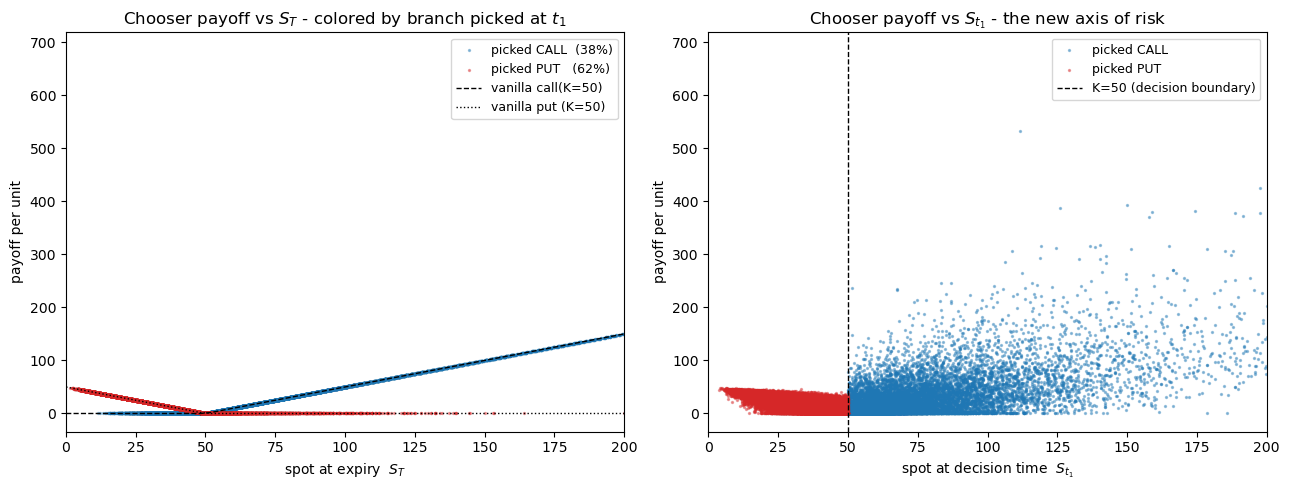

In [99]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: payoff vs S_T, colored by which branch was picked
ax = axes[0]
ax.scatter(spot_at_3w_expiry[ holder_picked_call],
           chooser_payoff_per_unit[ holder_picked_call],
           s=2, alpha=0.4, color='C0',
           label=f'picked CALL  ({holder_picked_call.mean():.0%})')
ax.scatter(spot_at_3w_expiry[~holder_picked_call],
           chooser_payoff_per_unit[~holder_picked_call],
           s=2, alpha=0.4, color='C3',
           label=f'picked PUT   ({(~holder_picked_call).mean():.0%})')
vanilla_xs = np.linspace(0.1, spot_at_3w_expiry.max(), 200)
ax.plot(vanilla_xs, np.maximum(vanilla_xs - chooser_strike, 0),
        'k--', lw=1, label=f'vanilla call(K={chooser_strike})')
ax.plot(vanilla_xs, np.maximum(chooser_strike - vanilla_xs, 0),
        'k:',  lw=1, label=f'vanilla put (K={chooser_strike})')
ax.set(xlabel='spot at expiry  $S_T$', ylabel='payoff per unit',
       title='Chooser payoff vs $S_T$ - colored by branch picked at $t_1$',
       xlim=(0, 200))
ax.legend(fontsize=9)

# Plot 2: payoff vs decision-time spot (the new axis)
ax = axes[1]
ax.scatter(spot_at_chooser_decision[ holder_picked_call],
           chooser_payoff_per_unit[ holder_picked_call],
           s=2, alpha=0.4, color='C0', label='picked CALL')
ax.scatter(spot_at_chooser_decision[~holder_picked_call],
           chooser_payoff_per_unit[~holder_picked_call],
           s=2, alpha=0.4, color='C3', label='picked PUT')
ax.axvline(chooser_strike, color='k', ls='--', lw=1,
           label=f'K={chooser_strike} (decision boundary)')
ax.set(xlabel='spot at decision time  $S_{t_1}$',
       ylabel='payoff per unit',
       title='Chooser payoff vs $S_{t_1}$ - the new axis of risk',
       xlim=(0, 200))
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

**Read these:**

*Left plot:* the chooser payoff sits ON the vanilla call curve for the blue dots and ON the vanilla put curve for the red dots — but at any single $S_T$, *both* colors can show up. Same expiry spot, different payoff. The hockey-stick-pair of vanilla intuition is replaced by an envelope.

*Right plot:* the colors split cleanly at $S_{t_1}=K$. Above $K$ the holder commits to the call branch; below, to the put branch. After $t_1$ the chooser is locked into one vanilla and rides $S_T$ from there. That's why each color shows its own scatter pattern — the spread within a color comes from $S_T$ moving freely between $t_1$ and $T$.

**Replication advisor mentioned (Rubinstein, $r=0$):**

$$\text{Chooser}(K, t_1, T) = \text{Call}(K, T) + \text{Put}(K, t_1)$$

Two listed legs match exactly: `AC_50_C` (call, 21d) + `AC_50_P_2` (put, 14d). This identity holds in **time-0 value**, not in path-by-path terminal payoff. Per-path differences cancel in expectation but not pointwise — keep that in mind when sizing the trade.

## Summary table — what new axis each exotic introduces

In [100]:
from textwrap import dedent
print(dedent('''
    Contract              State that determines payoff           Vanilla equivalent state
    --------------------  -------------------------------------  ------------------------
    Vanilla call/put      S_T                                    S_T (baseline)
    Binary put            S_T                                    S_T (still 1D, but step)
    Knock-out put         (S_T, min_t S_t)                       S_T  -> NEW AXIS: min S
    Chooser option        (S_T, S_t1)                            S_T  -> NEW AXIS: S_t1

    Trading takeaway:
      Wherever an exotic introduces a new state axis, vanilla replication is
      imperfect.  The advisor wants us to hedge the new axis with the listed
      vanillas.  Next notebook: build those replication portfolios and look at
      the residual exposure (the part the vanillas can't see).
''').strip())

Contract              State that determines payoff           Vanilla equivalent state
--------------------  -------------------------------------  ------------------------
Vanilla call/put      S_T                                    S_T (baseline)
Binary put            S_T                                    S_T (still 1D, but step)
Knock-out put         (S_T, min_t S_t)                       S_T  -> NEW AXIS: min S
Chooser option        (S_T, S_t1)                            S_T  -> NEW AXIS: S_t1

Trading takeaway:
  Wherever an exotic introduces a new state axis, vanilla replication is
  imperfect.  The advisor wants us to hedge the new axis with the listed
  vanillas.  Next notebook: build those replication portfolios and look at
  the residual exposure (the part the vanillas can't see).
